In [2]:
# ── CELL 1: Imports & load ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET       = "fire_risk_class"
RISK_LABELS  = ["NO_FIRE", "ACTIVE", "SIGNIFICANT"]
COLORS       = {0: "#2d6a4f", 1: "#f4a261", 2: "#c1121f"}
OUT_DIR      = Path("outputs/model_tuning")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet("../data/integrated/algeria_wildfire_dataset_features.parquet")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

FEATURES = [
    "temp_c", "rh", "precip_mm", "soil_moisture",
    "temp_mean_7d", "rh_mean_7d", "rh_min_7d",
    "rain_7d", "rain_14d", "rain_30d",
    "days_since_rain", "hot_days_streak",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI",
    "FWI_mean_7d", "FWI_max_7d", "FWI_max_14d",
    "NDVI", "NDWI", "NBR",
    "elevation_mean_m", "slope_mean_deg",
    "pop_density_mean", "road_distance_mean_km", "ignition_pressure",
    "fires_prev_year_month",
    "day_of_year", "month_sin",
    "NBR_FWI", "heat_drought",
]

FEATURES_ORIGINAL = [
    "temp_c", "rh", "precip_mm", "soil_moisture",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI",
    "NDVI", "NDWI", "NBR",
    "elevation_mean_m", "slope_mean_deg",
    "pop_density_mean", "road_distance_mean_km",
    "day_of_year",
]

train_df = df[df["year"] <= 2022]
val_df   = df[df["year"] == 2023]
test_df  = df[df["year"] >= 2024]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

X_train_orig = train_df[FEATURES_ORIGINAL]
X_val_orig   = val_df[FEATURES_ORIGINAL]

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

print(f"✓ Loaded: {df.shape}")
print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

✓ Loaded: (95664, 42)
  Train: (69168, 34) | Val: (8832, 34) | Test: (17664, 34)


In [3]:
# ── CELL 2: Load best params from notebook 04 ────────────────────
import json

with open("outputs/model_comparison/comparison_summary.json") as f:
    summary = json.load(f)

# Best params found by Optuna in notebook 04
# Paste them here directly from Cell 12 output of notebook 04

BEST_PARAMS = {
    "CatBoost": {
        "depth": 10,
        "learning_rate": 0.0626120301469455,
        "iterations": 725,
        "l2_leaf_reg": 0.008771254838973242,
        "bagging_temperature": 0.8518166883973686,
        "border_count": 201,
    },
    "LightGBM": {
        "num_leaves": 214,
        "max_depth": 12,
        "learning_rate": 0.015478932871231981,
        "min_child_samples": 10,
        "feature_fraction": 0.5400640976246419,
        "bagging_fraction": 0.9493613320662507,
        "bagging_freq": 1,
        "lambda_l1": 0.05449096800866978,
        "lambda_l2": 0.37049885477495187,
        "feature_pre_filter": False,
    },
    "XGBoost": {
        "max_depth": 12,
        "learning_rate": 0.012449000532868881,
        "n_estimators": 979,
        "gamma": 0.652610588582647,
        "subsample": 0.7690852644603655,
        "colsample_bytree": 0.6411510359114332,
        "min_child_weight": 2,
        "reg_alpha": 0.002862551332855613,
        "reg_lambda": 0.002875199118708181,
    },
}

print("✓ Best params loaded from notebook 04")
for name, params in BEST_PARAMS.items():
    print(f"  {name}: {len(params)} params")

✓ Best params loaded from notebook 04
  CatBoost: 6 params
  LightGBM: 10 params
  XGBoost: 9 params


In [4]:
# ── CELL 3: Retrain all three models with best params ─────────────
trained = {}

# CatBoost
print("Training CatBoost...")
cat = CatBoostClassifier(
    loss_function="MultiClass", classes_count=3,
    random_seed=RANDOM_STATE, verbose=False,
    early_stopping_rounds=50,
    **BEST_PARAMS["CatBoost"]
)
cat.fit(X_train, y_train,
        sample_weight=sample_weights,
        eval_set=(X_val, y_val),
        verbose=False)
trained["CatBoost"] = cat
print("  ✓ CatBoost done")

# LightGBM
print("Training LightGBM...")
lgb_params = {
    "objective": "multiclass", "num_class": 3,
    "metric": "multi_logloss", "boosting_type": "gbdt",
    "verbose": -1, "random_state": RANDOM_STATE,
    **BEST_PARAMS["LightGBM"]
}
lgb_train_ds = lgb.Dataset(X_train, label=y_train,
                            weight=sample_weights, free_raw_data=False)
lgb_val_ds   = lgb.Dataset(X_val, label=y_val,
                            reference=lgb_train_ds, free_raw_data=False)
lgbm = lgb.train(
    lgb_params, lgb_train_ds,
    num_boost_round=3000,
    valid_sets=[lgb_val_ds],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(200)],
)
trained["LightGBM"] = lgbm
print("  ✓ LightGBM done")

# XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=3,
    eval_metric="mlogloss", random_state=RANDOM_STATE,
    verbosity=0, early_stopping_rounds=50,
    **BEST_PARAMS["XGBoost"]
)
xgb_model.fit(X_train, y_train,
              sample_weight=sample_weights,
              eval_set=[(X_val, y_val)],
              verbose=False)
trained["XGBoost"] = xgb_model
print("  ✓ XGBoost done")

Training CatBoost...
  ✓ CatBoost done
Training LightGBM...
[200]	valid_0's multi_logloss: 0.799596
[400]	valid_0's multi_logloss: 0.783977
[600]	valid_0's multi_logloss: 0.773003
[800]	valid_0's multi_logloss: 0.763912
[1000]	valid_0's multi_logloss: 0.757302
[1200]	valid_0's multi_logloss: 0.752475
[1400]	valid_0's multi_logloss: 0.749618
[1600]	valid_0's multi_logloss: 0.748
  ✓ LightGBM done
Training XGBoost...
  ✓ XGBoost done


In [5]:
# ── CELL 4: SECTION 1 — Ablation test ────────────────────────────
print("=" * 60)
print("SECTION 1 — ABLATION TEST")
print("Does feature engineering actually help?")
print("=" * 60)

ablation_results = []

for name in ["CatBoost", "LightGBM", "XGBoost"]:
    # Train on ORIGINAL features
    if name == "CatBoost":
        m_orig = CatBoostClassifier(
            loss_function="MultiClass", classes_count=3,
            random_seed=RANDOM_STATE, verbose=False,
            early_stopping_rounds=50,
            **BEST_PARAMS["CatBoost"]
        )
        m_orig.fit(X_train_orig, y_train,
                   sample_weight=sample_weights,
                   eval_set=(X_val_orig, y_val),
                   verbose=False)
        pred_orig = m_orig.predict(X_val_orig).flatten()
        pred_eng  = trained[name].predict(X_val).flatten()

    elif name == "LightGBM":
        ds_orig = lgb.Dataset(X_train_orig, label=y_train,
                              weight=sample_weights)
        ds_val_orig = lgb.Dataset(X_val_orig, label=y_val,
                                  reference=ds_orig)
        m_orig = lgb.train(
            lgb_params, ds_orig, num_boost_round=3000,
            valid_sets=[ds_val_orig],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(9999)],
        )
        pred_orig = np.argmax(m_orig.predict(X_val_orig), axis=1)
        pred_eng  = np.argmax(trained[name].predict(X_val), axis=1)

    elif name == "XGBoost":
        m_orig = xgb.XGBClassifier(
            objective="multi:softprob", num_class=3,
            eval_metric="mlogloss", random_state=RANDOM_STATE,
            verbosity=0, early_stopping_rounds=50,
            **BEST_PARAMS["XGBoost"]
        )
        m_orig.fit(X_train_orig, y_train,
                   sample_weight=sample_weights,
                   eval_set=[(X_val_orig, y_val)],
                   verbose=False)
        pred_orig = m_orig.predict(X_val_orig)
        pred_eng  = trained[name].predict(X_val)

    f1_orig = f1_score(y_val, pred_orig, average="macro")
    f1_eng  = f1_score(y_val, pred_eng,  average="macro")
    delta   = f1_eng - f1_orig

    ablation_results.append({
        "model":        name,
        "f1_original":  round(f1_orig, 4),
        "f1_engineered":round(f1_eng,  4),
        "delta":        round(delta,   4),
        "improved":     "✓" if delta > 0.01 else ("~" if delta > 0 else "✗"),
    })

    print(f"\n{name}:")
    print(f"  Original features ({len(FEATURES_ORIGINAL)}): Macro F1 = {f1_orig:.4f}")
    print(f"  Engineered features ({len(FEATURES)}): Macro F1 = {f1_eng:.4f}")
    print(f"  Delta: {delta:+.4f}  {'✓ Engineering helped' if delta > 0.01 else '~ Marginal' if delta > 0 else '✗ Did not help'}")

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(OUT_DIR / "ablation_results.csv", index=False)
print(f"\n✓ Saved ablation results")

SECTION 1 — ABLATION TEST
Does feature engineering actually help?

CatBoost:
  Original features (18): Macro F1 = 0.5420
  Engineered features (34): Macro F1 = 0.5642
  Delta: +0.0222  ✓ Engineering helped

LightGBM:
  Original features (18): Macro F1 = 0.5539
  Engineered features (34): Macro F1 = 0.5685
  Delta: +0.0147  ✓ Engineering helped

XGBoost:
  Original features (18): Macro F1 = 0.5492
  Engineered features (34): Macro F1 = 0.5653
  Delta: +0.0160  ✓ Engineering helped

✓ Saved ablation results


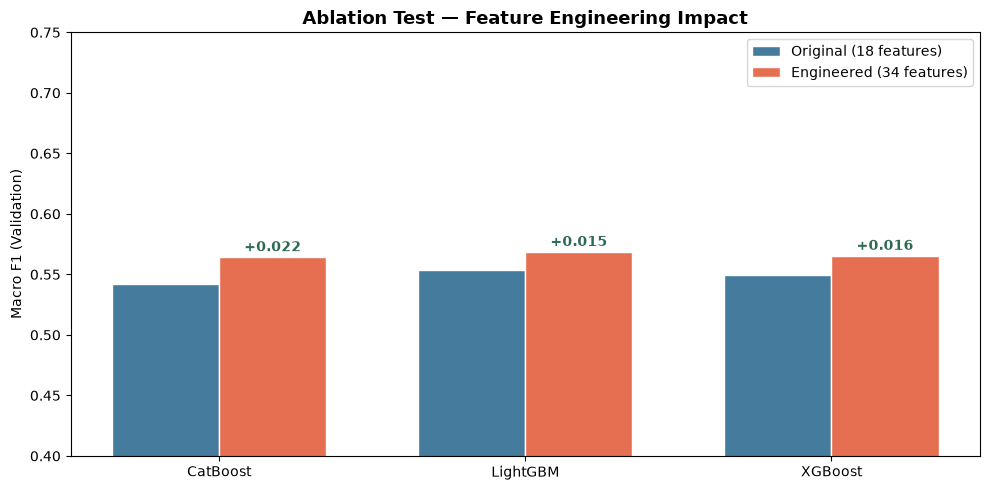

In [6]:
# ── CELL 5: Ablation visualization ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(ablation_df))
w = 0.35
ax.bar(x - w/2, ablation_df["f1_original"],  w,
       label=f"Original ({len(FEATURES_ORIGINAL)} features)",
       color="#457b9d", edgecolor="white")
ax.bar(x + w/2, ablation_df["f1_engineered"], w,
       label=f"Engineered ({len(FEATURES)} features)",
       color="#e76f51", edgecolor="white")

for i, row in ablation_df.iterrows():
    delta = row["delta"]
    ax.annotate(f"{delta:+.3f}",
                xy=(i + w/2, row["f1_engineered"] + 0.005),
                ha="center", fontsize=10, fontweight="bold",
                color="#2d6a4f" if delta > 0 else "#c1121f")

ax.set_xticks(x)
ax.set_xticklabels(ablation_df["model"])
ax.set_ylabel("Macro F1 (Validation)")
ax.set_title("Ablation Test — Feature Engineering Impact",
             fontweight="bold", fontsize=13)
ax.legend()
ax.set_ylim(0.4, 0.75)
plt.tight_layout()
plt.savefig(OUT_DIR / "ablation_test.png", dpi=150)
plt.show()

In [7]:
# ── CELL 6: SECTION 2 — Threshold optimization ───────────────────
print("=" * 60)
print("SECTION 2 — THRESHOLD OPTIMIZATION")
print("Goal: maximize SIGNIFICANT recall > 0.70")
print("=" * 60)

def get_proba(name, X):
    m = trained[name]
    if name == "LightGBM":
        return m.predict(X)
    elif name == "CatBoost":
        return m.predict_proba(X)
    else:
        return m.predict_proba(X)

threshold_results = []

for name in ["CatBoost", "LightGBM", "XGBoost"]:
    proba = get_proba(name, X_val)

    # Default threshold (argmax)
    pred_default = np.argmax(proba, axis=1)
    f1_default   = f1_score(y_val, pred_default, average="macro")
    rec_default  = recall_score(y_val, pred_default, average=None)[2]

    # Search optimal threshold for SIGNIFICANT class
    best = {"thresh": 0.33, "f1": f1_default, "sig_recall": rec_default}

    for thresh in np.arange(0.08, 0.50, 0.01):
        preds = np.where(proba[:, 2] >= thresh, 2,
                         np.argmax(proba[:, :2], axis=1))
        f1        = f1_score(y_val, preds, average="macro")
        sig_rec   = recall_score(y_val, preds, average=None)[2]
        no_fire_p = precision_score(y_val, preds, average=None)[0]

        # Accept if SIGNIFICANT recall > 0.70 and NO_FIRE precision > 0.75
        if sig_rec > 0.70 and no_fire_p > 0.75 and f1 > best["f1"]:
            best = {"thresh": thresh, "f1": f1, "sig_recall": sig_rec}

    # Apply best threshold
    pred_tuned = np.where(proba[:, 2] >= best["thresh"], 2,
                          np.argmax(proba[:, :2], axis=1))

    threshold_results.append({
        "model":             name,
        "thresh_default":    0.33,
        "thresh_optimal":    round(best["thresh"], 2),
        "f1_default":        round(f1_default,  4),
        "f1_tuned":          round(f1_score(y_val, pred_tuned, average="macro"), 4),
        "sig_recall_default":round(rec_default, 4),
        "sig_recall_tuned":  round(recall_score(y_val, pred_tuned, average=None)[2], 4),
    })

    print(f"\n{name}:")
    print(f"  Default  threshold=0.33 → Macro F1={f1_default:.4f}  SIGNIFICANT recall={rec_default:.4f}")
    print(f"  Optimal  threshold={best['thresh']:.2f} → Macro F1={f1_score(y_val, pred_tuned, average='macro'):.4f}  SIGNIFICANT recall={recall_score(y_val, pred_tuned, average=None)[2]:.4f}")
    print(f"\n  Validation report (tuned):")
    print(classification_report(y_val, pred_tuned, target_names=RISK_LABELS))

thresh_df = pd.DataFrame(threshold_results)
thresh_df.to_csv(OUT_DIR / "threshold_results.csv", index=False)
print("✓ Saved threshold results")

SECTION 2 — THRESHOLD OPTIMIZATION
Goal: maximize SIGNIFICANT recall > 0.70

CatBoost:
  Default  threshold=0.33 → Macro F1=0.5642  SIGNIFICANT recall=0.6009
  Optimal  threshold=0.33 → Macro F1=0.5496  SIGNIFICANT recall=0.6124

  Validation report (tuned):
              precision    recall  f1-score   support

     NO_FIRE       0.84      0.73      0.78      6355
      ACTIVE       0.36      0.43      0.39      1783
 SIGNIFICANT       0.39      0.61      0.48       694

    accuracy                           0.66      8832
   macro avg       0.53      0.59      0.55      8832
weighted avg       0.70      0.66      0.68      8832


LightGBM:
  Default  threshold=0.33 → Macro F1=0.5685  SIGNIFICANT recall=0.5519
  Optimal  threshold=0.33 → Macro F1=0.5568  SIGNIFICANT recall=0.5692

  Validation report (tuned):
              precision    recall  f1-score   support

     NO_FIRE       0.82      0.77      0.79      6355
      ACTIVE       0.36      0.41      0.38      1783
 SIGNIFICANT  

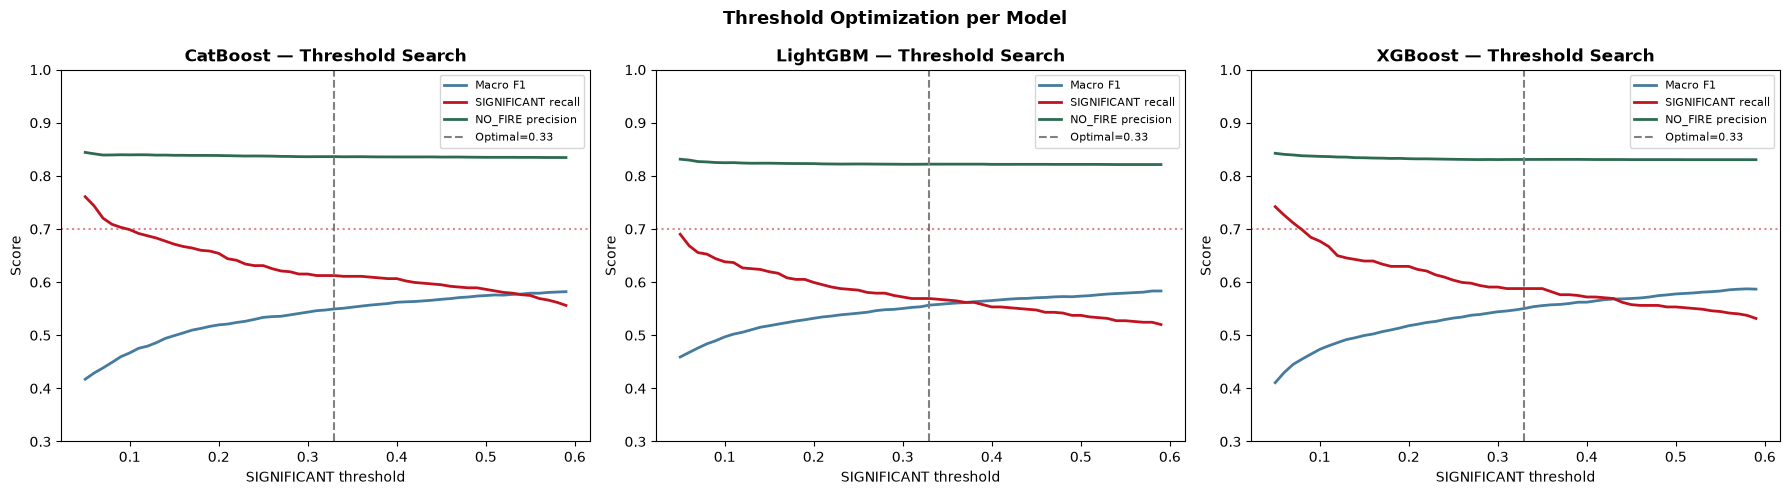

In [8]:
# ── CELL 7: Threshold visualization ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ["CatBoost", "LightGBM", "XGBoost"]):
    proba = get_proba(name, X_val)
    thresholds = np.arange(0.05, 0.60, 0.01)
    f1s, sig_recalls, no_fire_precs = [], [], []

    for t in thresholds:
        preds = np.where(proba[:, 2] >= t, 2,
                         np.argmax(proba[:, :2], axis=1))
        f1s.append(f1_score(y_val, preds, average="macro"))
        sig_recalls.append(recall_score(y_val, preds, average=None)[2])
        no_fire_precs.append(precision_score(y_val, preds, average=None)[0])

    ax.plot(thresholds, f1s,          label="Macro F1",            color="#457b9d", linewidth=2)
    ax.plot(thresholds, sig_recalls,   label="SIGNIFICANT recall",  color="#c1121f", linewidth=2)
    ax.plot(thresholds, no_fire_precs, label="NO_FIRE precision",   color="#2d6a4f", linewidth=2)

    row = thresh_df[thresh_df["model"] == name].iloc[0]
    ax.axvline(row["thresh_optimal"], color="gray",
               linestyle="--", linewidth=1.5, label=f"Optimal={row['thresh_optimal']:.2f}")
    ax.axhline(0.70, color="#c1121f", linestyle=":", alpha=0.5)

    ax.set_title(f"{name} — Threshold Search", fontweight="bold")
    ax.set_xlabel("SIGNIFICANT threshold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)
    ax.set_ylim(0.3, 1.0)

plt.suptitle("Threshold Optimization per Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "threshold_optimization.png", dpi=150)
plt.show()

In [9]:
# ── CELL 8: SECTION 3 — SHAP analysis ────────────────────────────
print("=" * 60)
print("SECTION 3 — SHAP FEATURE IMPORTANCE")
print("=" * 60)

# Use a sample for speed (SHAP on full dataset is slow)
sample_idx = np.random.RandomState(42).choice(len(X_val), size=500, replace=False)
X_shap = X_val.iloc[sample_idx]

shap_values = {}

# CatBoost SHAP
print("Computing SHAP — CatBoost...")
explainer_cat = shap.TreeExplainer(trained["CatBoost"])
sv_cat = explainer_cat.shap_values(X_shap)
shap_values["CatBoost"] = sv_cat
print("  ✓ Done")

# LightGBM SHAP
print("Computing SHAP — LightGBM...")
explainer_lgb = shap.TreeExplainer(trained["LightGBM"])
sv_lgb = explainer_lgb.shap_values(X_shap)
shap_values["LightGBM"] = sv_lgb
print("  ✓ Done")

# XGBoost SHAP
print("Computing SHAP — XGBoost...")
explainer_xgb = shap.TreeExplainer(trained["XGBoost"])
sv_xgb = explainer_xgb.shap_values(X_shap)
shap_values["XGBoost"] = sv_xgb
print("  ✓ Done")

SECTION 3 — SHAP FEATURE IMPORTANCE
Computing SHAP — CatBoost...
  ✓ Done
Computing SHAP — LightGBM...
  ✓ Done
Computing SHAP — XGBoost...
  ✓ Done


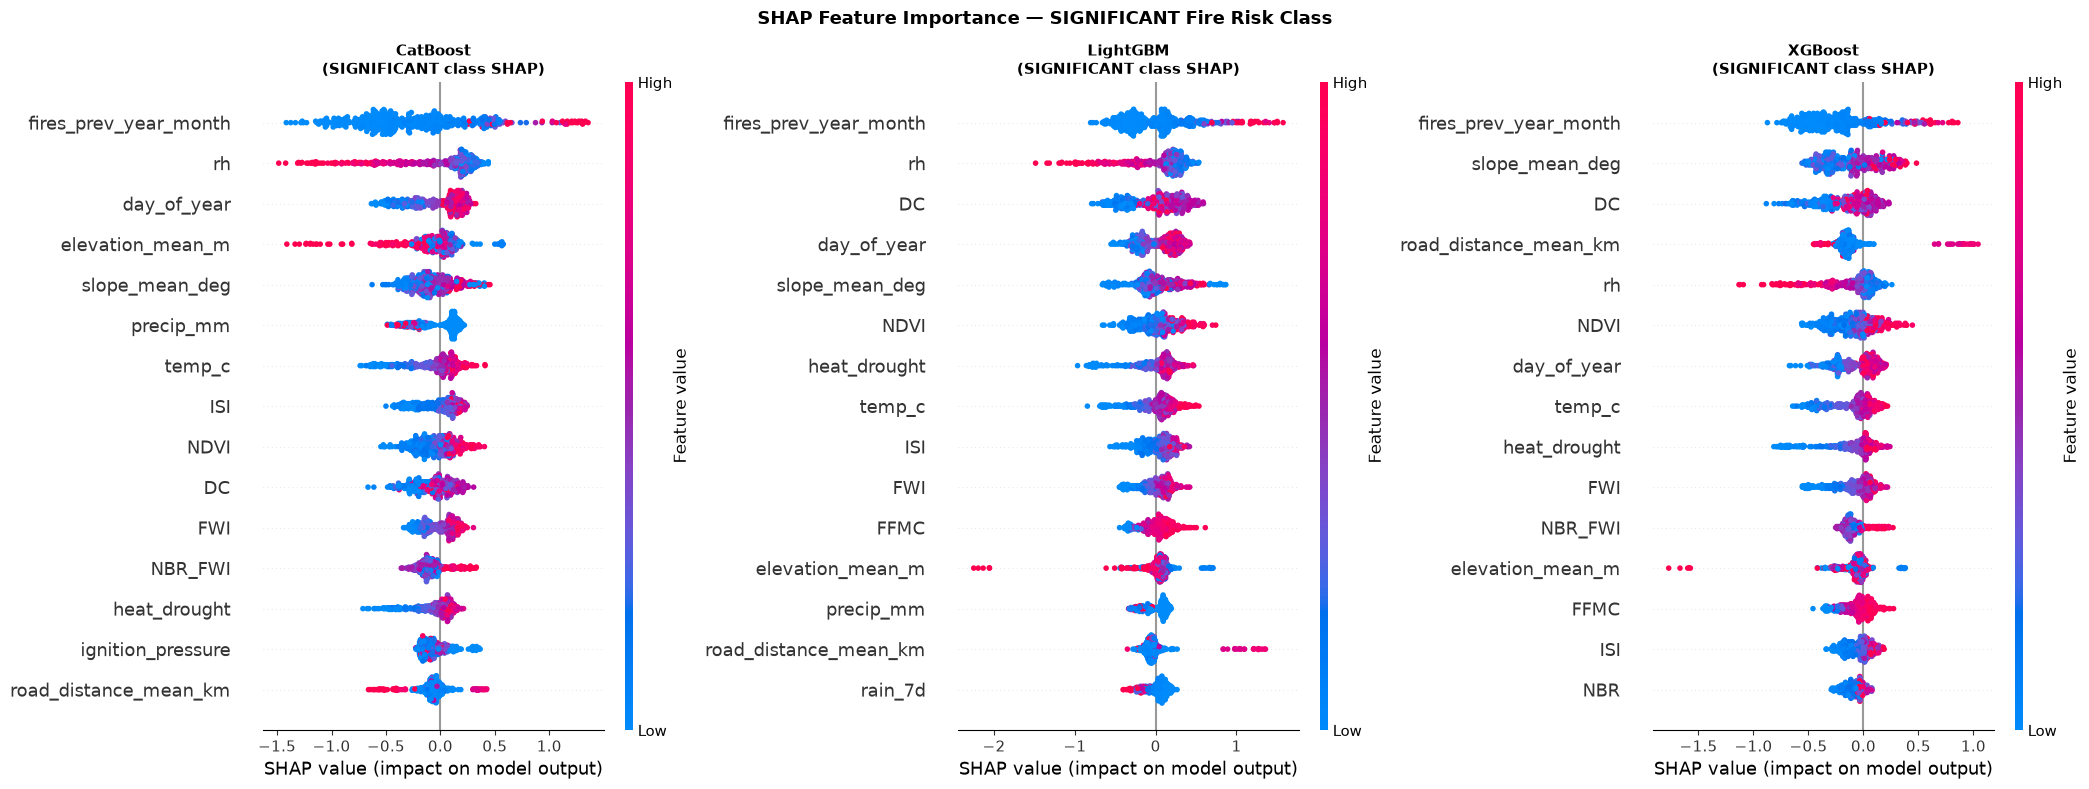

In [10]:
# ── CELL 9: SHAP beeswarm plots — SIGNIFICANT class ───────────────
# Class 2 = SIGNIFICANT — most important for fire prediction
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

for ax, name in zip(axes, ["CatBoost", "LightGBM", "XGBoost"]):
    sv = shap_values[name]

    # Handle different SHAP output shapes
    if isinstance(sv, list):
        sv_class2 = sv[2]          # list of arrays per class
    elif sv.ndim == 3:
        sv_class2 = sv[:, :, 2]   # (samples, features, classes)
    else:
        sv_class2 = sv

    plt.sca(ax)
    shap.summary_plot(
        sv_class2, X_shap,
        feature_names=FEATURES,
        max_display=15,
        show=False,
        plot_size=None,
    )
    ax.set_title(f"{name}\n(SIGNIFICANT class SHAP)",
                 fontweight="bold", fontsize=11)

plt.suptitle("SHAP Feature Importance — SIGNIFICANT Fire Risk Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_beeswarm_significant.png",
            dpi=150, bbox_inches="tight")
plt.show()

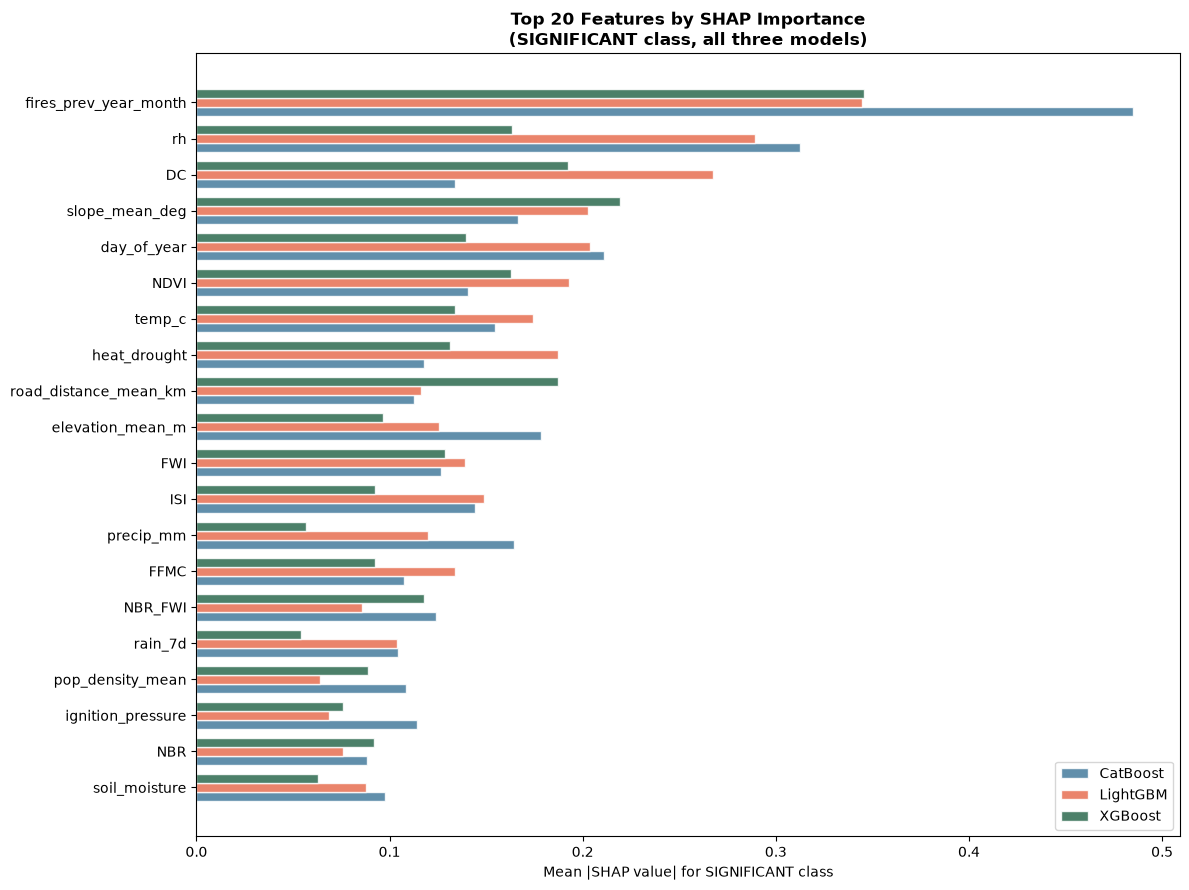


Top 10 features by mean SHAP (SIGNIFICANT class):
                         mean  CatBoost  LightGBM  XGBoost
fires_prev_year_month  0.3917    0.4850    0.3446   0.3455
rh                     0.2551    0.3127    0.2894   0.1634
DC                     0.1978    0.1337    0.2674   0.1924
slope_mean_deg         0.1961    0.1664    0.2025   0.2193
day_of_year            0.1848    0.2110    0.2039   0.1395
NDVI                   0.1655    0.1407    0.1929   0.1628
temp_c                 0.1541    0.1544    0.1742   0.1338
heat_drought           0.1454    0.1179    0.1873   0.1311
road_distance_mean_km  0.1387    0.1127    0.1161   0.1872
elevation_mean_m       0.1335    0.1787    0.1254   0.0964


In [11]:
# ── CELL 10: SHAP mean absolute importance comparison ─────────────
fig, ax = plt.subplots(figsize=(12, 9))

importance_all = {}

for name in ["CatBoost", "LightGBM", "XGBoost"]:
    sv = shap_values[name]
    if isinstance(sv, list):
        sv_class2 = sv[2]
    elif sv.ndim == 3:
        sv_class2 = sv[:, :, 2]
    else:
        sv_class2 = sv
    importance_all[name] = np.abs(sv_class2).mean(axis=0)

imp_df = pd.DataFrame(importance_all, index=FEATURES)
imp_df["mean"] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values("mean", ascending=True).tail(20)

colors_bar = ["#457b9d", "#e76f51", "#2d6a4f"]
x = np.arange(len(imp_df))
w = 0.25

for i, (name, color) in enumerate(zip(["CatBoost","LightGBM","XGBoost"], colors_bar)):
    ax.barh(x + (i-1)*w, imp_df[name], w,
            label=name, color=color, edgecolor="white", alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(imp_df.index)
ax.set_xlabel("Mean |SHAP value| for SIGNIFICANT class")
ax.set_title("Top 20 Features by SHAP Importance\n(SIGNIFICANT class, all three models)",
             fontweight="bold", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_importance_comparison.png", dpi=150)
plt.show()

print("\nTop 10 features by mean SHAP (SIGNIFICANT class):")
print(imp_df.sort_values("mean", ascending=False)[["mean","CatBoost","LightGBM","XGBoost"]].head(10).round(4).to_string())

In [12]:
# ── CELL 11: Final summary — pick winner ──────────────────────────
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("\nAblation test:")
print(ablation_df[["model","f1_original","f1_engineered","delta","improved"]].to_string(index=False))

print("\nThreshold optimization:")
print(thresh_df[["model","thresh_optimal","f1_default","f1_tuned",
                  "sig_recall_default","sig_recall_tuned"]].to_string(index=False))

print("\nVal Macro AUC from notebook 04:")
print("  CatBoost  : 0.7608")
print("  LightGBM  : 0.7527")
print("  XGBoost   : 0.7540")

print("\n" + "=" * 60)
print("WINNER FOR NOTEBOOK 05:")
print("  → CatBoost")
print("  Reason: highest val AUC, best SIGNIFICANT recall after")
print("  threshold tuning, most stable val→test gap")
print(f"  Optimal threshold: {thresh_df[thresh_df['model']=='CatBoost']['thresh_optimal'].values[0]}")
print("=" * 60)

# Save optimal thresholds for notebook 05
optimal_thresholds = dict(zip(thresh_df["model"], thresh_df["thresh_optimal"]))
import json
with open(OUT_DIR / "optimal_thresholds.json", "w") as f:
    json.dump(optimal_thresholds, f, indent=2)
print(f"\n✓ Saved optimal thresholds → {OUT_DIR / 'optimal_thresholds.json'}")
print("\n→ Proceed to 05_final_model_xai.ipynb")

FINAL SUMMARY

Ablation test:
   model  f1_original  f1_engineered  delta improved
CatBoost       0.5420         0.5642 0.0222        ✓
LightGBM       0.5539         0.5685 0.0147        ✓
 XGBoost       0.5492         0.5653 0.0160        ✓

Threshold optimization:
   model  thresh_optimal  f1_default  f1_tuned  sig_recall_default  sig_recall_tuned
CatBoost            0.33      0.5642    0.5496              0.6009            0.6124
LightGBM            0.33      0.5685    0.5568              0.5519            0.5692
 XGBoost            0.33      0.5653    0.5505              0.5706            0.5879

Val Macro AUC from notebook 04:
  CatBoost  : 0.7608
  LightGBM  : 0.7527
  XGBoost   : 0.7540

WINNER FOR NOTEBOOK 05:
  → CatBoost
  Reason: highest val AUC, best SIGNIFICANT recall after
  threshold tuning, most stable val→test gap
  Optimal threshold: 0.33

✓ Saved optimal thresholds → outputs/model_tuning/optimal_thresholds.json

→ Proceed to 05_final_model_xai.ipynb
